# Training cWGAN-GP for Minority Class Oversampling - GMSC
 
This notebook trains an enhanced Conditional Wasserstein GAN with Gradient Penalty (cWGAN-GP) to generate synthetic minority class samples for the German Credit dataset.
 
**Improvements over baseline:**
- MinMaxScaler for numerical features (output range [0,1], no negatives)
- Sigmoid activation in generator numerical head
- Latent dimension increased to 256
- Gumbel-Softmax for categorical generation
- Training for 3000 epochs
- Post-generation clipping to original feature ranges

In [ ]:
%load_ext autoreload

In [ ]:
%autoreload 2

## 1. Setup and Imports

In [4]:

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import tensorflow as tf
import joblib

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

from gan_util import build_feature_info, split_num_cat, combine_num_cat
from cwgan_gp import CWGANGP
from evaluation import *
from data_balancing import (
    prepare_minority_data_for_gan, 
    train_cwgan_on_minority,
    generate_synthetic_samples,            
    prepare_full_data_for_gan, 
    train_cwgan_full
)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [5]:
# Check TensorFlow GPU availability (optional)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.12.0
GPU Available: []


## 2. Load Processed Data and Feature Info

In [ ]:
# Load one-hot encoded data (from feature engineering)
df_processed = pd.read_csv("../data/processed/gmsc_processed_onehot.csv")
print("Shape:", df_processed.shape)
df_processed.head()


Shape: (149318, 33)


,Class,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfTime30-59DaysPastDueNotWorse_0,NumberOfTime30-59DaysPastDueNotWorse_1,NumberOfTime30-59DaysPastDueNotWorse_2,...,NumberOfTime60-89DaysPastDueNotWorse_1,NumberOfTime60-89DaysPastDueNotWorse_2,NumberOfTime60-89DaysPastDueNotWorse_3,NumberOfTime60-89DaysPastDueNotWorse_98,NumberOfDependents_0,NumberOfDependents_1,NumberOfDependents_2,NumberOfDependents_3,NumberOfDependents_4,NumberOfDependents_5
0,1,0.766127,45,0.802982,9120.0,13,4,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,0,0.957151,40,0.121876,2600.0,4,0,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,0,0.658180,38,0.085113,3042.0,2,0,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,0,0.233810,30,0.036050,3300.0,5,0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,0.907239,49,0.024926,10749.0,7,1,False,True,False,...,False,False,False,False,True,False,False,False,False,False


In [7]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149318 entries, 0 to 149317
Data columns (total 33 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Class                                    149318 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines     149318 non-null  float64
 2   age                                      149318 non-null  int64  
 3   DebtRatio                                149318 non-null  float64
 4   MonthlyIncome                            149318 non-null  float64
 5   NumberOfOpenCreditLinesAndLoans          149318 non-null  int64  
 6   NumberRealEstateLoansOrLines             149318 non-null  int64  
 7   NumberOfTime30-59DaysPastDueNotWorse_0   149318 non-null  bool   
 8   NumberOfTime30-59DaysPastDueNotWorse_1   149318 non-null  bool   
 9   NumberOfTime30-59DaysPastDueNotWorse_2   149318 non-null  bool   
 10  NumberOfTime30-59DaysPastDueNotW

In [ ]:
# Load feature info and column order
feature_info = joblib.load("../models/feature_info_gmsc.pkl")
column_order = joblib.load("../models/column_order_gmsc.pkl")
cat_cols_original = joblib.load("../models/cat_cols_gmsc.pkl")

print("Numerical features:", feature_info['numerical'])
print("Categorical groups:")
for k, v in feature_info['categorical'].items():
    print(f"  {k}: {len(v)} categories")


Numerical features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
Categorical groups:
  NumberOfTime30-59DaysPastDueNotWorse: 8 categories
  NumberOfTimes90DaysLate: 7 categories
  NumberOfTime60-89DaysPastDueNotWorse: 5 categories
  NumberOfDependents: 6 categories


## 3. Check Class Imbalance

In [ ]:
target_col = 'Class'
minority_label = 1  # bad credit

counts = df_processed[target_col].value_counts()
print(counts)
print(f"Imbalance ratio: {counts[0] / counts[1]:.2f}:1")


Class
0    139589
1      9729
Name: count, dtype: int64
Imbalance ratio: 14.35:1


## 4. Prepare Full Data for GAN (with MinMaxScaler and Conditioning)

In [ ]:
# 1. Prepare the dataset for training (this also fits the scaler internally)
dataset, scaler, n_num, n_cat_dims, num_scaled, cat_list = prepare_full_data_for_gan(
    df_processed,              # ← full 1000 samples
    feature_info,
    target_col,
    minority_label,
    batch_size=64
)

# 3. Print the desired output
print("Total samples:", len(df_processed))
if n_num > 0:
    print("Numerical features shape (scaled 0-1):", num_scaled.shape)
    print("Numerical value ranges:")
    for i, col in enumerate(feature_info['numerical']):
        print(f"  {col}: min={num_scaled[:, i].min():.4f}, max={num_scaled[:, i].max():.4f}")
for i, arr in enumerate(cat_list):
    print(f"Categorical group {i} shape: {arr.shape}")

print(f"\nDataset ready. Numerical features: {n_num}, Categorical groups: {len(n_cat_dims)}")

Total samples: 149318
Numerical features shape (scaled 0-1): (149318, 6)
Numerical value ranges:
  RevolvingUtilizationOfUnsecuredLines: min=0.0000, max=1.0000
  age: min=0.0000, max=1.0000
  DebtRatio: min=0.0000, max=1.0000
  MonthlyIncome: min=0.0000, max=1.0000
  NumberOfOpenCreditLinesAndLoans: min=0.0000, max=1.0000
  NumberRealEstateLoansOrLines: min=0.0000, max=1.0000
Categorical group 0 shape: (149318, 8)
Categorical group 1 shape: (149318, 7)
Categorical group 2 shape: (149318, 5)
Categorical group 3 shape: (149318, 6)

Dataset ready. Numerical features: 6, Categorical groups: 4


## 5. Train cWGAN-GP on Full Samples

In [ ]:
gan, scaler = train_cwgan_full(
    df_train=df_processed,      
    feature_info=feature_info,
    target_col=target_col,
    minority_label=minority_label,
    latent_dim=256,
    epochs=3000,
    batch_size=64,
    n_critic=5,
    gp_weight=10.0,
    aux_weight=1.0,
    learning_rate=1e-4,
    gumbel_temperature=0.5,
    verbose=True,
    save_path='../models/cwgan_gmsc_full/'
)

Epoch 10/3000 | C Loss: -0.0966 | G Loss: -2.2130 | W Dist: 0.0982 | GP: 0.0029
Epoch 20/3000 | C Loss: -0.0708 | G Loss: -2.2536 | W Dist: 0.0721 | GP: 0.0026
Epoch 30/3000 | C Loss: -0.0630 | G Loss: -1.8958 | W Dist: 0.0635 | GP: 0.0025
Epoch 40/3000 | C Loss: -0.0585 | G Loss: -1.7716 | W Dist: 0.0605 | GP: 0.0023
Epoch 50/3000 | C Loss: -0.0516 | G Loss: -1.8599 | W Dist: 0.0523 | GP: 0.0021

Early stopping at epoch 51 (Wasserstein distance did not improve for 50 epochs)

Training completed! Best Wasserstein Distance: 0.3305
Model saved to ../models/cwgan_gmsc_full/


## 6. Generate Synthetic Samples and Evaluate Quality

In [ ]:
# Generate a small batch for visualization
n_vis = 10000
cond_vis = np.ones((n_vis, 1), dtype=np.float32)
num_synth_scaled, cat_synth = gan.generate(cond_vis, batch_size=64)

# Inverse scale numericals
if num_synth_scaled is not None:
    num_synth = scaler.inverse_transform(num_synth_scaled)
    print("Numerical value ranges after inverse transform:")
    for i, col in enumerate(feature_info['numerical']):
        print(f"  {col}: min={num_synth[:, i].min():.2f}, max={num_synth[:, i].max():.2f}")
else:
    num_synth = None

# Combine into DataFrame
df_synth_vis = combine_num_cat(num_synth, cat_synth, feature_info, column_order)


Numerical value ranges after inverse transform:
  RevolvingUtilizationOfUnsecuredLines: min=0.00, max=1.09
  age: min=21.22, max=96.09
  DebtRatio: min=0.00, max=1269.00
  MonthlyIncome: min=4.41, max=10749.00
  NumberOfOpenCreditLinesAndLoans: min=0.01, max=18.00
  NumberRealEstateLoansOrLines: min=0.00, max=4.00



NUMERICAL FEATURE RANGE COMPARISON

                           FULL DATASET (All Applicants)                          
  Feature                                                   Min             Max
  ---------------------------------------------------------------------------
  RevolvingUtilizationOfUnsecuredLines                     0.00            1.09
  age                                                     21.00          100.00
  DebtRatio                                                0.00         1269.00
  MonthlyIncome                                            0.00        10749.00
  NumberOfOpenCreditLinesAndLoans                          0.00           18.00
  NumberRealEstateLoansOrLines                             0.00            4.00

                          REAL MINORITY CLASS (Defaulters)                        
  Feature                                                   Min             Max
  ---------------------------------------------------------------------------


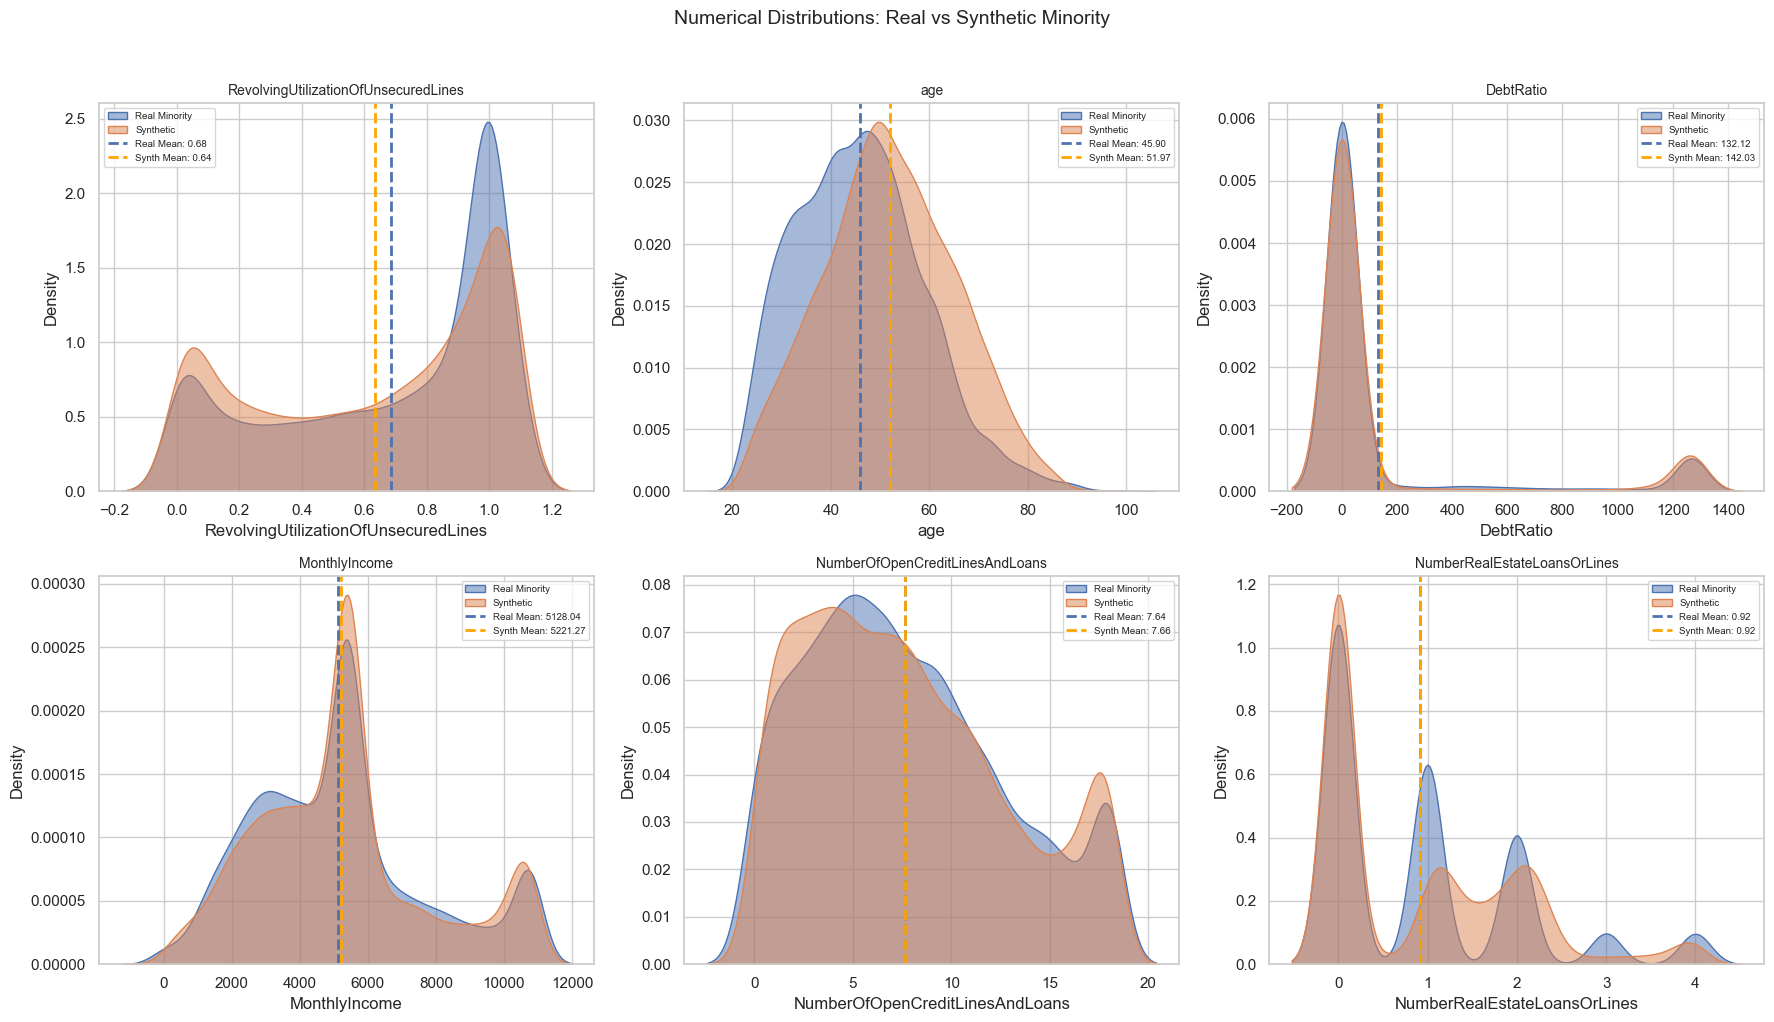

Plotting categorical proportions with value labels...


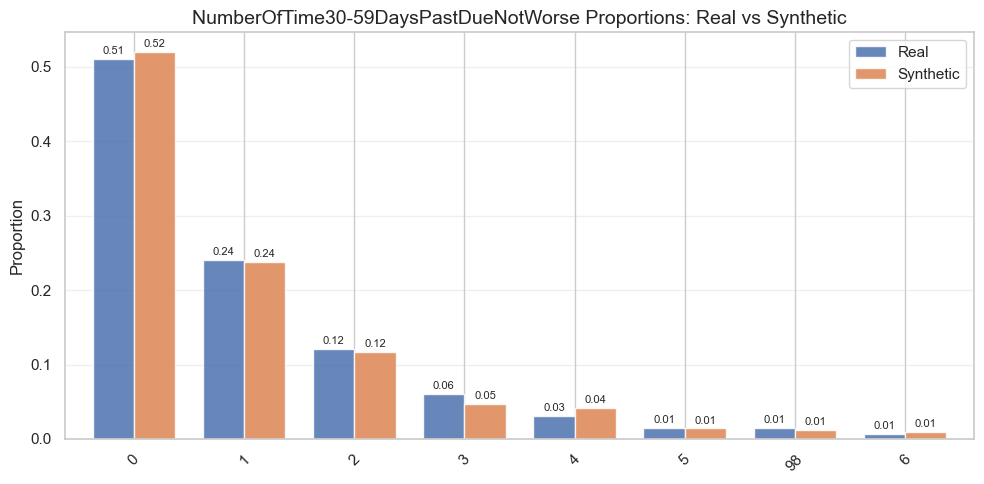

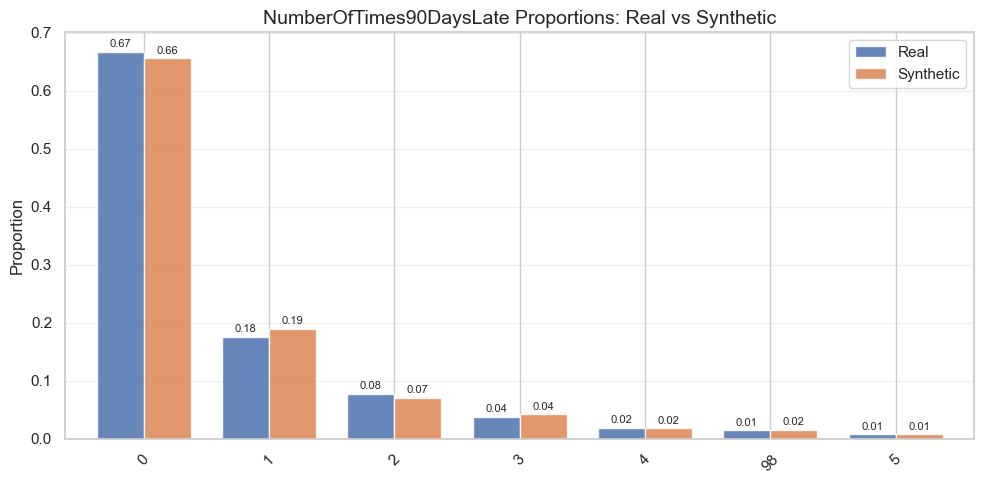

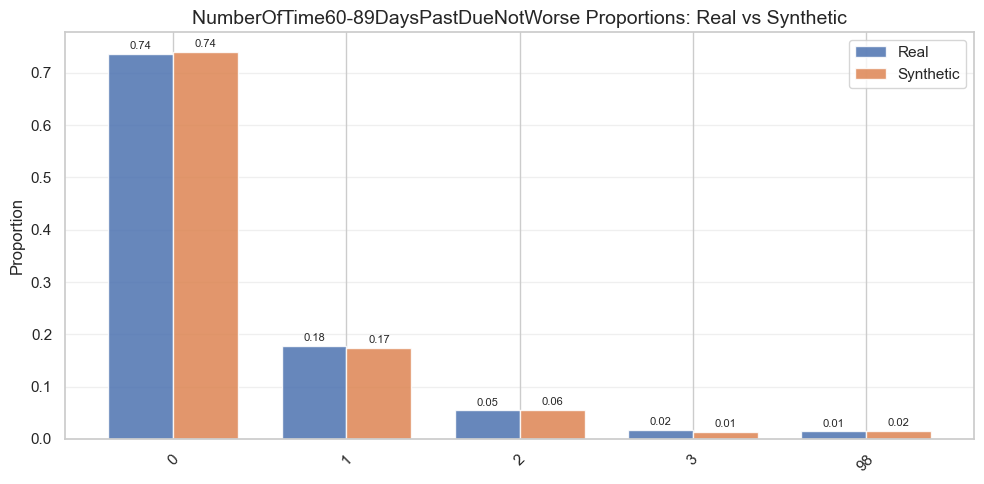

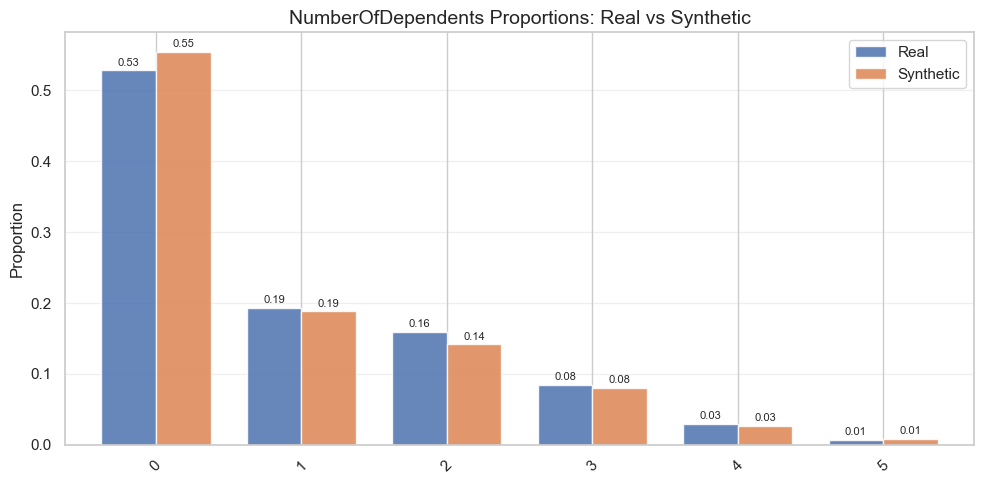

Plotting correlation matrices...


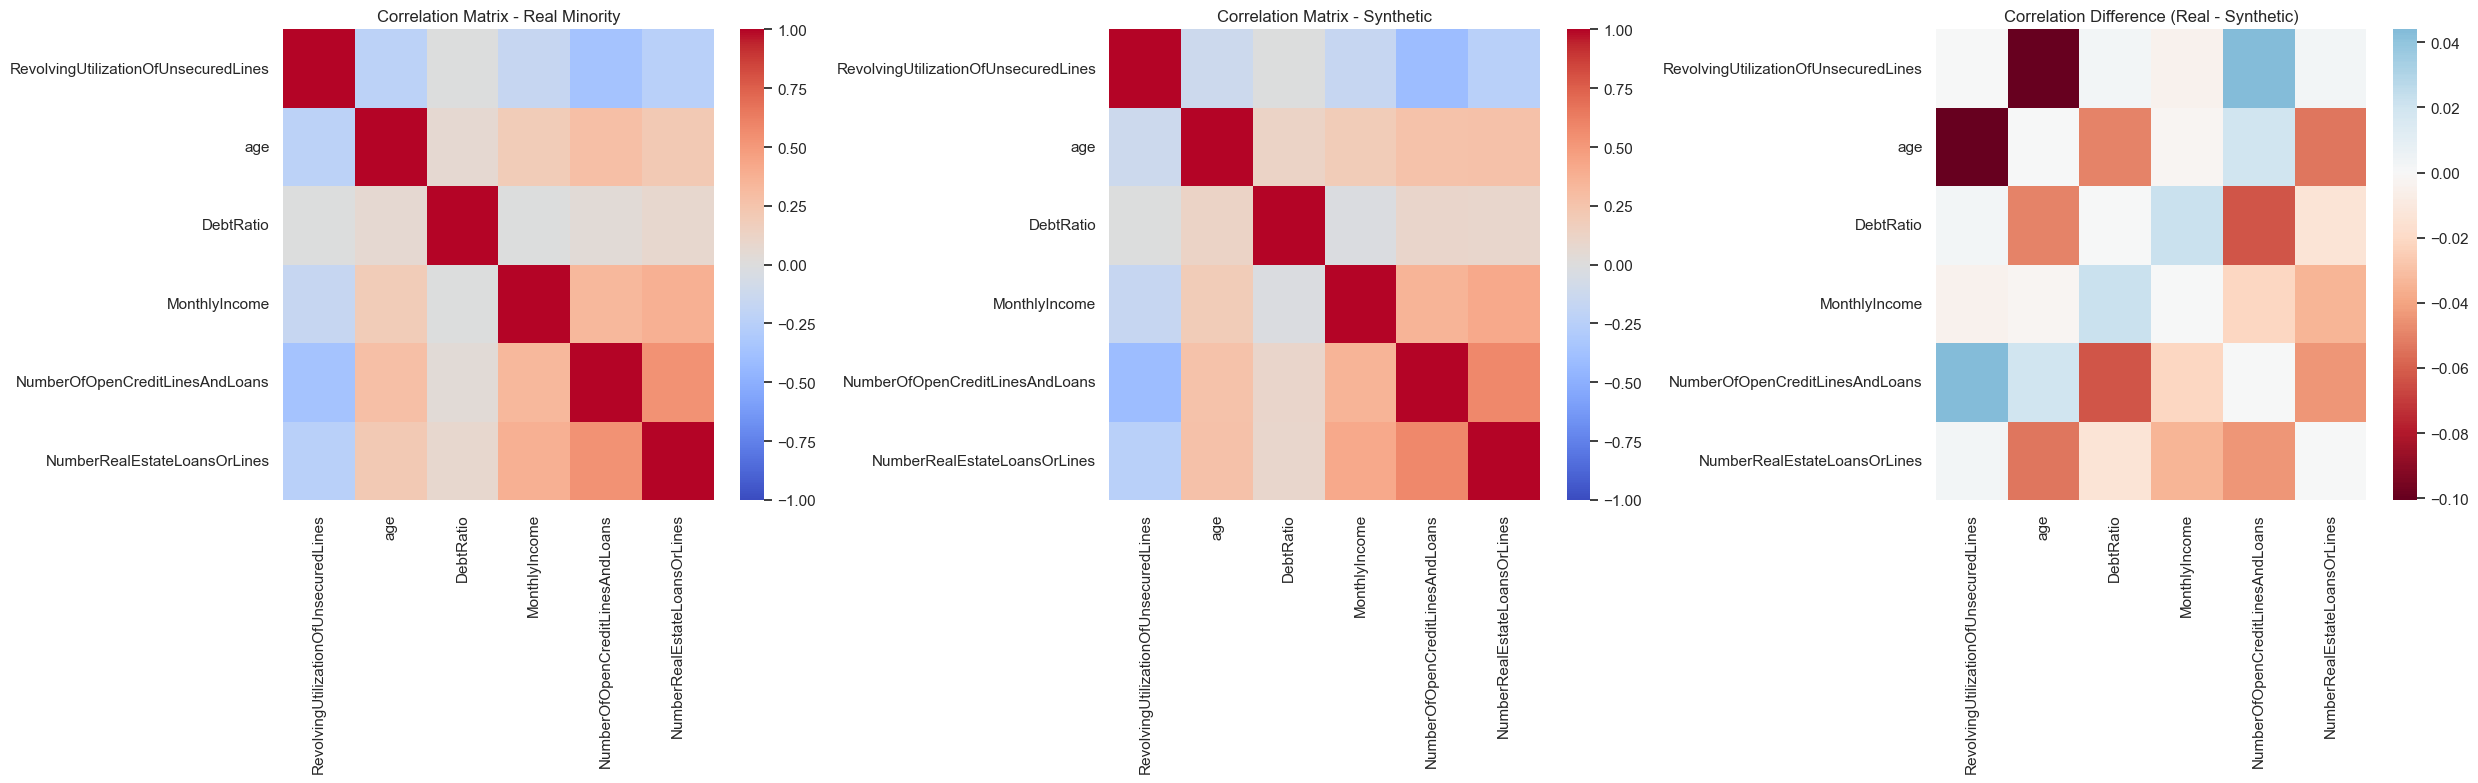

Generating PCA/t‑SNE projections...


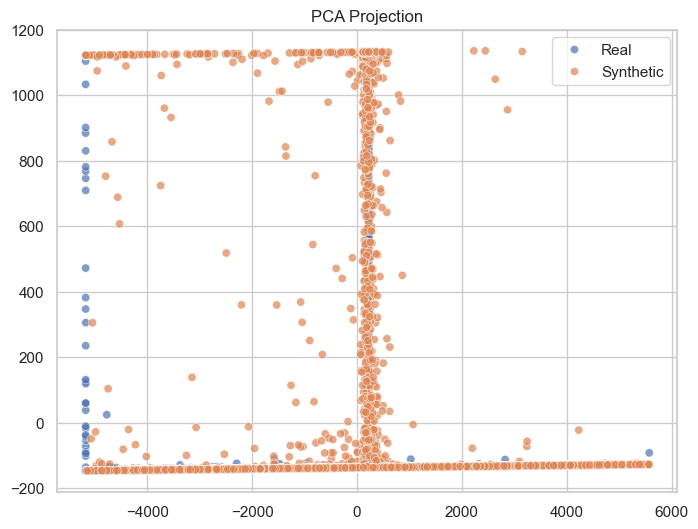

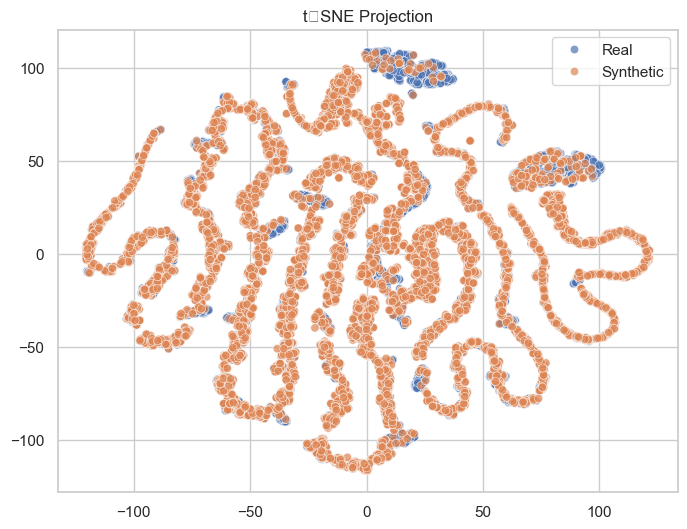


SYNTHETIC DATA QUALITY REPORT

1. NUMERICAL FEATURE STATISTICS:
  Feature                                        Real Mean Synth Mean Mean Diff%   Real Std  Synth Std  Std Diff%
  ---------------------------------------------------------------------------------------------------------
  RevolvingUtilizationOfUnsecuredLines                0.68       0.64       7.1%       0.36       0.37       3.2%
  age                                                45.90      51.97      13.2%      12.98      13.38       3.1%
  DebtRatio                                         132.12     142.03       7.5%     359.42     381.44       6.1%
  MonthlyIncome                                    5128.04    5221.27       1.8%    2581.68    2553.13       1.1%
  NumberOfOpenCreditLinesAndLoans                     7.64       7.66       0.3%       5.01       5.10       1.7%
  NumberRealEstateLoansOrLines                        0.92       0.92       0.5%       1.09       1.08       0.3%

2. CATEGORICAL FEATURE FIDEL

In [15]:
# In cwgan_training.ipynb, after Section 7
results = evaluate_generative_quality(
    df_synth_vis=df_synth_vis,
    feature_info=feature_info,
    df_processed=df_processed,
    target_col=target_col,
    minority_label=minority_label,
    save_path='../figures'
)

## 7. Balance the Full Dataset 

In [ ]:
# Compute feature ranges from full dataset for clipping
feature_ranges = {col: (df_processed[col].min(), df_processed[col].max()) 
                  for col in feature_info['numerical']}

# Generate enough synthetic samples to balance the entire dataset
majority_count = (df_processed[target_col] != minority_label).sum()
minority_count = (df_processed[target_col] == minority_label).sum()
needed = majority_count - minority_count
#needed = 10000
print(f"Full dataset: Majority={majority_count}, Minority={minority_count}, Need {needed} synthetic samples.")

if needed > 0:
    df_synth_full = generate_synthetic_samples(
        gan, scaler, needed, feature_info, column_order,
        minority_label=minority_label, target_col=target_col, feature_ranges=feature_ranges
    )
    df_balanced = pd.concat([df_processed, df_synth_full], ignore_index=True)
    print("Balanced shape:", df_balanced.shape)
    print("Class counts after balancing:")
    print(df_balanced[target_col].value_counts())
    
    # Save balanced dataset
    df_balanced.to_csv("../data/processed/gmsc_balanced_cwgan_improved.csv", index=False)
    print("Balanced dataset saved to ../data/processed/gmsc_balanced_cwgan_improved.csv")
else:
    print("Dataset already balanced.")

# %% [markdown]
# ## 9. Next Steps
# - Train XGBoost on the balanced dataset
# - Compare with SMOTE and original imbalanced data using proper train/test split
# - Apply SHAP for explainability

Full dataset: Majority=139589, Minority=9729, Need 129860 synthetic samples.
Balanced shape: (279178, 33)
Class counts after balancing:
Class
1    139589
0    139589
Name: count, dtype: int64
Balanced dataset saved to ../data/processed/gmsc_balanced_cwgan_improved.csv
